In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import run_logit, split_test_train

In [2]:
X_train = np.loadtxt("arcene/ARCENE/arcene_train.data")
y_train = np.loadtxt("arcene/ARCENE/arcene_train.labels")
X_test = np.loadtxt("arcene/ARCENE/arcene_valid.data")
y_test = np.loadtxt("arcene/arcene_valid.labels")

In [3]:
X_train.shape

(100, 10000)

In [11]:
# Setup
random_state=50
num_iter=100
rng=np.random.default_rng(random_state)
p=100
n_vals = np.linspace(30,200,30)
kappas = p/n_vals

0/30
1/30
2/30
3/30
4/30
5/30
6/30
7/30
8/30
9/30
10/30
11/30
12/30
13/30
14/30
15/30
16/30
17/30
18/30
19/30
20/30
21/30
22/30
23/30
24/30
25/30
26/30
27/30
28/30
29/30


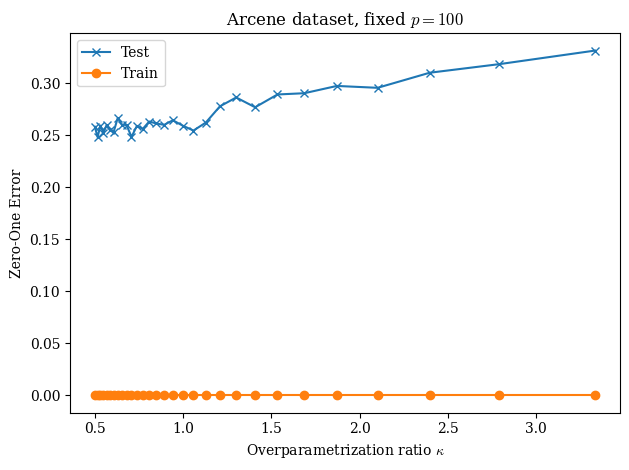

In [13]:
train_errors=[]
test_errors=[]
for n_idx,n in enumerate(n_vals):
    print(f'{n_idx}/{len(n_vals)}')
    listy_test=np.zeros(num_iter)
    listy_train=np.zeros(num_iter)
    for t in range(num_iter):

        X_train_t, y_train_t, X_test_t, y_test_t, selected_cols = split_test_train(X_train,y_train,int(p),int(n),rng)
        errors = run_logit(X_train_t,y_train_t,X_test[:, selected_cols],y_test)
        listy_train[t]=(errors["train_error"])
        listy_test[t]=(errors["test_error"])
    train_errors.append(np.mean(listy_train))
    test_errors.append(np.mean(listy_test))
    
plt.rcParams.update({'font.family': 'serif','mathtext.fontset': 'cm',})

plt.plot(kappas,test_errors,marker='x',label='Test')
plt.plot(kappas,train_errors,marker='o',label='Train')
plt.ylabel('Zero-One Error')
plt.xlabel(r'Overparametrization ratio $\kappa$')
plt.title(r'Arcene dataset, fixed $p=100$')
plt.legend()
plt.tight_layout()
plt.savefig('arcene_2.png',dpi=400)

